In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pairwise_distance_functions as fnc

import matplotlib
font = {'size'   : 12}
matplotlib.rc('font', **font)

In [53]:
# Import metadata and calculate the number of repeats per opa gene
metadata = pd.read_csv('../../results/opa_metadata_locus.csv', index_col = 0)

metadata.dropna(subset = ['id'], inplace = True)
metadata.reset_index(inplace = True, drop = True)

# Label opas with if there is another opa in the strain that is nearly the same
within_strain_distance = pd.read_csv('../../results/pairwise_distance/within_strain_pairwise_distance_aa.csv', index_col = 0)
similar_opas = np.unique(np.concatenate([within_strain_distance[within_strain_distance['distance']<=0.05]['id_A'].values, within_strain_distance[within_strain_distance['distance']<=0.05]['id_B'].values]))

metadata['similar_within_strain'] = 'N'
metadata.loc[metadata['id'].isin(similar_opas), 'similar_within_strain'] = 'Y'

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

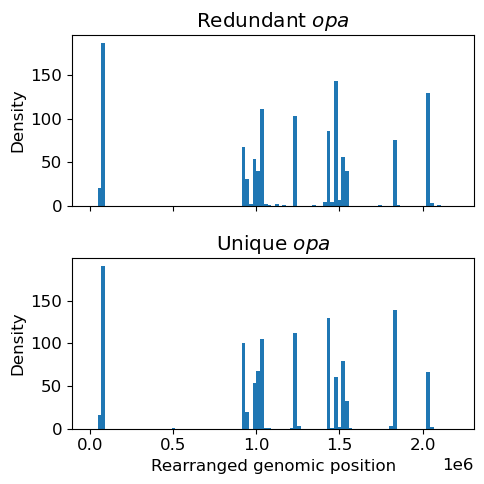

In [57]:
# Plot the rearranged genomic positions
fig, ax = plt.subplots(2,1, figsize = (5,5), sharex = True)
ax[0].hist(metadata[metadata['similar_within_strain']=='Y']['start_reordered_flipped'], bins = np.linspace(0, 2.2*10**6, 100))
ax[1].hist(metadata[metadata['similar_within_strain']=='N']['start_reordered_flipped'], bins = np.linspace(0, 2.2*10**6, 100))
ax[1].set_xlabel('Rearranged genomic position')
ax[0].set_ylabel('Density')
ax[1].set_ylabel('Density')
ax[0].set_title('Redundant $opa$')
ax[1].set_title('Unique $opa$')
plt.savefig('../../figures/diversity/within_strain_similar_aa_rearranged_location.png', dpi = 300)
plt.savefig('../../figures/diversity/within_strain_similar_aa_rearranged_location.pdf')
plt.tight_layout()
plt.show()

# Get the between-strain diversity of the unique and redundant opa

Note that we exclude the within-strain diversity comparison so as to not bias the
redundant opa diversity calculation (since by definition the within-strain diversity of the
redundant opa will be very low

In [21]:
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import AlignIO
from Bio.Phylo.TreeConstruction import DistanceCalculator
from Bio.Align import MultipleSeqAlignment

In [28]:
# Load amino acid alignment
aln = AlignIO.read('../../results/alignments/opa_sequences_aa.fa.aln', 'fasta')

In [36]:
# Get alignment of just redundant opa
redundant_opa = metadata[metadata['similar_within_strain']=='Y']['id'].values
aln_redundant_list = [record for record in aln if record.id in redundant_opa]
aln_redundant = MultipleSeqAlignment(aln_redundant_list)

# Get alignment of just unique opa
unique_opa = metadata[metadata['similar_within_strain']=='N']['id'].values
aln_unique_list = [record for record in aln if record.id in unique_opa]
aln_unique = MultipleSeqAlignment(aln_unique_list)

In [37]:
# Calculate distance between all pairs of sequences in list of unique or redundant opa
calculator = DistanceCalculator('identity')
dm_unique = calculator.get_distance(aln_unique)
dm_redundant = calculator.get_distance(aln_redundant)

In [42]:
# Function for getting the between-strain opa distance for a distance matrix of opa distances
def get_between_strain_opa_distance(dm):
    matrix = dm.matrix
    
    # Convert distance output list to array
    matrix_array = np.empty((len(matrix), len(matrix)))
    matrix_array.fill(np.nan)
    for i in range(len(matrix)):
        matrix_array[i, 0:i+1] = matrix[i]
    
    # Replace zeros on diagonal with nan
    np.fill_diagonal(matrix_array, np.nan)
    
    # Get the strain name from the opa gene name
    ids = dm.names
        
    strains = []
    opa_gene_nums = []
    for id_i in ids:
        strain, opa_gene_num = fnc.parse_opa_name(id_i)
        strains.append(strain)
        opa_gene_nums.append(opa_gene_num)
    
    ids_metadata = pd.DataFrame({'id':ids, 'strain':strains, 'opa_gene_nums':opa_gene_nums})
    
    # Calculate the between-strain distance
    
    matrix_array_between_strains = np.copy(matrix_array)
    for strain, df in ids_metadata.groupby('strain'):
        idx_strain = df.index
        matrix_array_between_strains[np.min(idx_strain):np.max(idx_strain)+1, np.min(idx_strain):np.max(idx_strain)+1] = np.nan
    
    between_strains_flattened = matrix_array_between_strains.flatten()
    between_strains_flattened_nonan = between_strains_flattened[~np.isnan(between_strains_flattened)]
    return between_strains_flattened_nonan

In [45]:
# Run function for unique and redundant opa
between_strains_flattened_nonan_unique = get_between_strain_opa_distance(dm_unique)
between_strains_flattened_nonan_redundant = get_between_strain_opa_distance(dm_redundant)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

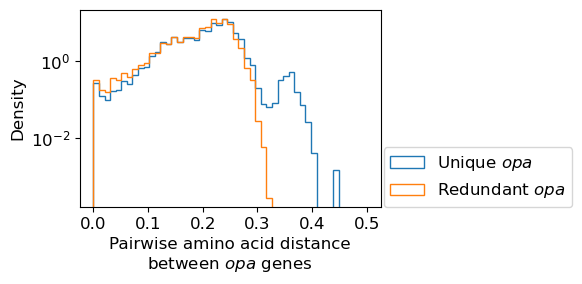

In [55]:
# Make plot
plt.figure(figsize = (6,3))
bins = np.linspace(0, 0.5, 50)
plt.hist(between_strains_flattened_nonan_unique, bins = bins, label = 'Unique $opa$', density = True, histtype = 'step')#, color = '#919BCA')
plt.hist(between_strains_flattened_nonan_redundant, bins = bins, label = 'Redundant $opa$', density = True, histtype = 'step')#, color = '#919BCA')
plt.xlabel('Pairwise amino acid distance\nbetween $opa$ genes')
plt.ylabel('Density')
plt.legend(loc = (1.01, 0))
plt.yscale('log')
plt.tight_layout()
plt.savefig("../../figures/diversity/within_strain_similar_aa_between_strain_distance.png", dpi = 300)
plt.savefig("../../figures/diversity/within_strain_similar_aa_between_strain_distance.pdf")
plt.show()